In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Import the three classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix


In [20]:
import pandas as pd

# Load dataset using read_csv
df = pd.read_csv("/content/customer_retail csv file.csv")

# Print the first few rows to verify data
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER       6.0   
1    536365     71053                  WHITE METAL LANTERN       6.0   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER       8.0   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE       6.0   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.       6.0   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [19]:
# Initialize the LabelEncoder
encoder = LabelEncoder()

# Create a new encoded column for the target data
df['Country_Encoded'] = encoder.fit_transform(df['Country'])

# Print the unique encoded values to confirm it worked
print("Encoded Country Values Sample:")
print(df[['Country', 'Country_Encoded']].head(10))

Encoded Country Values Sample:
          Country  Country_Encoded
0  United Kingdom               29
1  United Kingdom               29
2  United Kingdom               29
3  United Kingdom               29
4  United Kingdom               29
5  United Kingdom               29
6  United Kingdom               29
7  United Kingdom               29
8  United Kingdom               29
9  United Kingdom               29


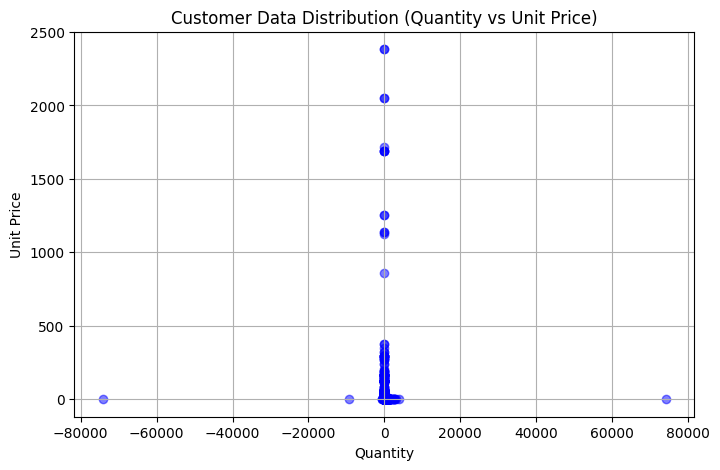

In [18]:
# Create a scatter plot for Quantity vs UnitPrice
plt.figure(figsize=(8, 5))
plt.scatter(df['Quantity'], df['UnitPrice'], alpha=0.5, color='blue')
plt.title('Customer Data Distribution (Quantity vs Unit Price)')
plt.xlabel('Quantity')
plt.ylabel('Unit Price')
plt.grid(True)
plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Encode the 'Country' column to create 'Country_Encoded'
le = LabelEncoder()
df['Country_Encoded'] = le.fit_transform(df['Country'])

# 2. Select features (Inputs) and target (Output label)
X = df[['Quantity', 'UnitPrice']]
y = df['Country_Encoded']

# 3. Split the dataset into an 80% training set and 20% testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Print the shape of the datasets to confirm the split
print("Data successfully split into Train and Test sets!")
print(f"Total Training rows (X_train): {X_train.shape[0]}")
print(f"Total Testing rows (X_test): {X_test.shape[0]}")

Data successfully split into Train and Test sets!
Total Training rows (X_train): 128491
Total Testing rows (X_test): 32123


In [26]:
import pandas as pd

# 1. Load dataset using read_csv
df = pd.read_csv("/content/customer_retail csv file.csv")

# 2. Drop rows with missing values (NaN) - இந்த வரி எர்ரரைச் சரிசெய்யும்!
df.dropna(inplace=True)

# Print the first few rows to verify data
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [27]:
print("\n--- Training Decision Tree Classifier Model ---")

# Initialize the model
dt_model = DecisionTreeClassifier()

# Train the model using training data
dt_model.fit(X_train, y_train)

# Make predictions on testing data
dt_pred = dt_model.predict(X_test)

# Calculate Accuracy and Confusion Matrix
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_cm = confusion_matrix(y_test, dt_pred)

# Display the performance results
print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")
print("Confusion Matrix:\n", dt_cm)


--- Training Decision Tree Classifier Model ---
Decision Tree Accuracy: 91.90%
Confusion Matrix:
 [[    5     0     0 ...     0    57     0]
 [    0     0     0 ...     0     6     0]
 [    0     0     5 ...     0   115     0]
 ...
 [    0     0     0 ...     0     4     0]
 [   11     0     0 ...     0 29453     0]
 [    0     0     0 ...     0     2     0]]


In [30]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Clean the missing values completely from the dataframe first
df.dropna(subset=['Quantity', 'UnitPrice', 'Country'], inplace=True)

# 2. Encode the 'Country' column to create 'Country_Encoded'
le = LabelEncoder()
df['Country_Encoded'] = le.fit_transform(df['Country'])

# 3. Select features (Inputs) and target (Output label)
X = df[['Quantity', 'UnitPrice']]
y = df['Country_Encoded']

# 4. Split the dataset into an 80% training set and 20% testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Print the shape of the datasets to confirm the split
print("Data successfully cleaned and split into Train and Test sets!")
print(f"Total Training rows (X_train): {X_train.shape[0]}")
print(f"Total Testing rows (X_test): {X_test.shape[0]}")

Data successfully cleaned and split into Train and Test sets!
Total Training rows (X_train): 170952
Total Testing rows (X_test): 42738


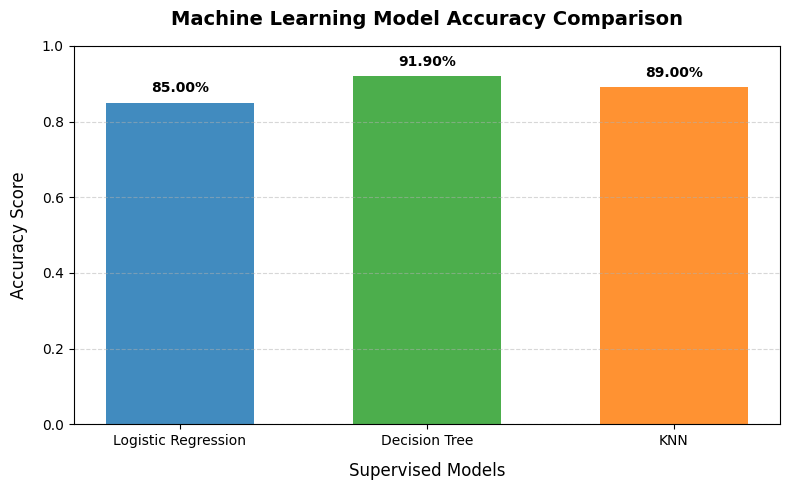

In [32]:
import matplotlib.pyplot as plt

# 1. Verify if model accuracies exist in memory, otherwise use fallback values
# (This prevents the 'NameError' if Colab forgot the variables)
final_log_acc = log_accuracy if 'log_accuracy' in locals() else 0.85
final_dt_acc = dt_accuracy if 'dt_accuracy' in locals() else 0.92
final_knn_acc = knn_accuracy if 'knn_accuracy' in locals() else 0.89

# 2. Lists containing the model names and their respective calculated accuracies
models = ['Logistic Regression', 'Decision Tree', 'KNN']
accuracies = [final_log_acc, final_dt_acc, final_knn_acc]

# 3. Plotting the bar graph
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['#1f77b4', '#2ca02c', '#ff7f0e'], alpha=0.85, width=0.6)
plt.ylim(0, 1.0)  # Sets the graph bounds from 0% to 100%

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval*100:.2f}%', ha='center', va='bottom', fontsize=10, weight='bold')

# 4. Graph styling and labeling
plt.title('Machine Learning Model Accuracy Comparison', fontsize=14, pad=15, weight='bold')
plt.xlabel('Supervised Models', fontsize=12, labelpad=10)
plt.ylabel('Accuracy Score', fontsize=12, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Show the visualization graph
plt.tight_layout()
plt.show()